In [ ]:
%load_ext sql
%sql mysql+mysqlconnector://root:<YOUR_PASSWORD>@localhost/company

In [ ]:
%%sql
show databases;

In [ ]:
%%sql
SHOW TABLES;

In [ ]:
%%sql
use test

In [ ]:
# 📊 Sales Performance Analysis using MySQL

## 📌 Project Overview

This project analyzes a company's sales data using MySQL to extract meaningful business insights. The analysis focuses on customer behavior, product performance, salesperson performance, regional sales, and revenue trends using SQL queries..

## 🎯 Objectives

- Analyze overall sales performance
- Identify top-performing products and customers
- Evaluate salesperson performance
- Compare sales across different regions
- Analyze monthly sales trends
- Apply SQL techniques to solve business problems

## 📂 Dataset

| Table | Records |
|--------|---------|
| Customers | 50 |
| Products | 30 |
| Salespersons | 15 |
| Sales | 500 |

## 🛠️ SQL Skills Demonstrated

- Data Definition Language (DDL)
- Primary & Foreign Keys
- INNER JOIN
- LEFT JOIN
- Aggregate Functions
- GROUP BY & HAVING
- CASE Statement
- Common Table Expressions (CTE)
- Window Functions
  - ROW_NUMBER()
  - RANK()
  - DENSE_RANK()
  - NTILE()
  - LAG()
  - LEAD()
- Date Functions
- Subqueries

In [ ]:
## 🗂 Database Schema

The project consists of four related tables:

• Customers
• Products
• Salespersons
• Sales

The Sales table acts as the fact table and references the remaining tables using foreign keys.

In [ ]:
## 🗂️ Database Schema (ER Diagram)

The database consists of four related tables:
- Customers
- Products
- Salespersons
- Sales

The Sales table acts as the fact table and references the remaining tables through foreign keys.

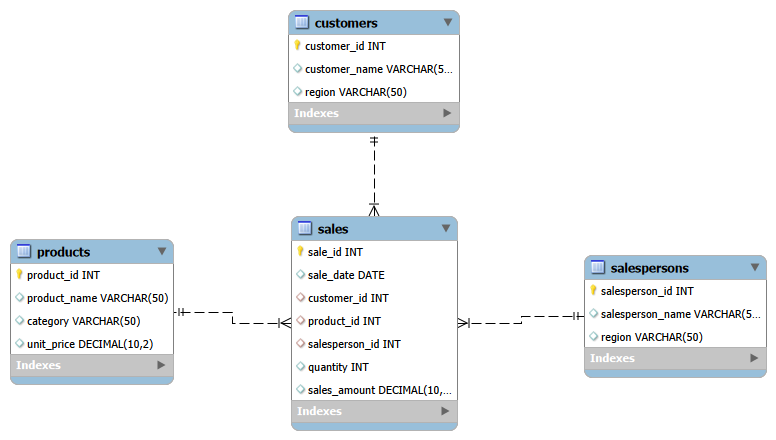

In [ ]:
# Database Creation

In [ ]:
## 1.Create Customers Table

In [ ]:
%%sql
create table Customers(
    customer_id int PRIMARY KEY,
    customer_name varchar(50),
    region varchar(50)
);

In [ ]:
## 2.Create Products Table

In [ ]:
%%sql
create table Products(
    product_id int PRIMARY KEY,
    product_name varchar(50),
    category varchar(50),
    unit_price decimal(10,2)
);

In [ ]:
## 3.Create Salespersons Table

In [ ]:
%%sql
create table Salespersons(
    salesperson_id int PRIMARY KEY,
    salesperson_name varchar(50),
    region varchar(50)
);

In [ ]:
## 4.Create Sales Table

In [ ]:
%%sql
create table Sales(
    sale_id int primary key,
    sale_date DATE,
    customer_id int,
    product_id int,
    salesperson_id int,
    quantity int,
    sales_amount decimal(10,2),
    FOREIGN KEY (customer_id)
        REFERENCES Customers(customer_id),

    FOREIGN KEY (product_id)
        REFERENCES Products(product_id),

    FOREIGN KEY (salesperson_id)
        REFERENCES Salespersons(salesperson_id)

    
);

In [ ]:
# Data Insertion

In [ ]:
## Insert Customers

In [ ]:
%%sql
INSERT INTO Customers (customer_id, customer_name, region) VALUES
(1,'Aarav Sharma','North'),
(2,'Priya Patel','West'),
(3,'Rahul Kumar','South'),
(4,'Ananya Singh','East'),
(5,'Vikram Reddy','South'),
(6,'Neha Gupta','North'),
(7,'Arjun Nair','West'),
(8,'Kavya Iyer','South'),
(9,'Rohit Verma','East'),
(10,'Sneha Joshi','North'),
(11,'Aditya Mehta','West'),
(12,'Pooja Shah','South'),
(13,'Karan Malhotra','East'),
(14,'Divya Rao','North'),
(15,'Manish Yadav','West'),
(16,'Aisha Khan','South'),
(17,'Harish Kumar','East'),
(18,'Meera Nair','North'),
(19,'Sanjay Gupta','West'),
(20,'Ritika Sharma','South'),
(21,'Deepak Singh','East'),
(22,'Nisha Patel','North'),
(23,'Varun Reddy','West'),
(24,'Aditi Verma','South'),
(25,'Rajesh Kumar','East'),
(26,'Ishita Rao','North'),
(27,'Mohit Sharma','West'),
(28,'Sonia Gupta','South'),
(29,'Ajay Patel','East'),
(30,'Kriti Nair','North'),
(31,'Abhishek Singh','West'),
(32,'Shreya Mehta','South'),
(33,'Nitin Verma','East'),
(34,'Tanvi Joshi','North'),
(35,'Gaurav Kumar','West'),
(36,'Rhea Shah','South'),
(37,'Akash Reddy','East'),
(38,'Pallavi Rao','North'),
(39,'Yash Gupta','West'),
(40,'Simran Kaur','South'),
(41,'Aman Sharma','East'),
(42,'Bhavna Patel','North'),
(43,'Rakesh Kumar','West'),
(44,'Komal Singh','South'),
(45,'Naveen Reddy','East'),
(46,'Sakshi Verma','North'),
(47,'Hemant Gupta','West'),
(48,'Nikita Rao','South'),
(49,'Tarun Sharma','East'),
(50,'Preeti Joshi','North');

In [ ]:
## Insert Products

In [ ]:
%%sql
INSERT INTO Products (product_id, product_name, category, unit_price) VALUES
(101,'Dell Laptop','Electronics',50000),
(102,'HP Laptop','Electronics',55000),
(103,'Lenovo Laptop','Electronics',48000),
(104,'iPhone 15','Mobile',80000),
(105,'Samsung Galaxy S24','Mobile',75000),
(106,'OnePlus 12','Mobile',45000),
(107,'Wireless Mouse','Accessories',1000),
(108,'Mechanical Keyboard','Accessories',3000),
(109,'Bluetooth Speaker','Accessories',2500),
(110,'Smart Watch','Accessories',5000),
(111,'Office Chair','Furniture',7000),
(112,'Study Table','Furniture',9000),
(113,'Bookshelf','Furniture',6000),
(114,'LED Monitor','Electronics',12000),
(115,'Printer','Electronics',10000),
(116,'Webcam','Accessories',2000),
(117,'Headphones','Accessories',3500),
(118,'Power Bank','Accessories',1500),
(119,'External SSD','Electronics',6000),
(120,'Router','Electronics',2500),
(121,'Air Conditioner','Appliances',35000),
(122,'Refrigerator','Appliances',28000),
(123,'Washing Machine','Appliances',25000),
(124,'Microwave Oven','Appliances',8000),
(125,'Vacuum Cleaner','Appliances',7000),
(126,'Ceiling Fan','Appliances',2500),
(127,'Water Purifier','Appliances',12000),
(128,'Tablet','Electronics',22000),
(129,'Projector','Electronics',30000),
(130,'Gaming Console','Electronics',40000);

In [ ]:
## Insert Salespersons

In [ ]:
%%sql
INSERT INTO Salespersons (salesperson_id, salesperson_name, region) VALUES
(1,'John Smith','North'),
(2,'David Wilson','South'),
(3,'Michael Brown','East'),
(4,'Emma Johnson','West'),
(5,'Sophia Davis','North'),
(6,'James Taylor','South'),
(7,'Olivia Martin','East'),
(8,'Daniel Clark','West'),
(9,'William Lee','North'),
(10,'Ava Walker','South'),
(11,'Benjamin Hall','East'),
(12,'Mia Allen','West'),
(13,'Lucas Young','North'),
(14,'Charlotte King','South'),
(15,'Ethan Scott','East');

In [ ]:
## Insert Sales

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(1, '2025-05-11', 10, 124, 9, 8, 64000),
(2, '2025-03-27', 48, 107, 13, 6, 6000),
(3, '2025-02-13', 21, 125, 14, 3, 21000),
(4, '2025-05-23', 49, 114, 3, 4, 48000),
(5, '2025-01-12', 23, 115, 10, 3, 30000),
(6, '2025-06-02', 37, 101, 12, 9, 450000),
(7, '2025-02-24', 4, 111, 3, 1, 7000),
(8, '2025-06-16', 15, 121, 2, 9, 315000),
(9, '2025-03-12', 2, 124, 13, 10, 80000),
(10, '2025-07-16', 31, 101, 5, 2, 100000),
(11, '2025-10-25', 2, 104, 14, 10, 800000),
(12, '2025-09-25', 15, 125, 6, 2, 14000),
(13, '2025-09-14', 48, 116, 15, 9, 18000),
(14, '2025-07-05', 16, 114, 7, 5, 60000),
(15, '2025-06-23', 22, 129, 3, 6, 180000),
(16, '2025-01-02', 43, 112, 5, 7, 63000),
(17, '2025-03-16', 44, 121, 10, 1, 35000),
(18, '2025-07-24', 3, 105, 2, 3, 225000),
(19, '2025-04-10', 16, 110, 5, 3, 15000),
(20, '2025-12-21', 24, 104, 5, 9, 720000),
(21, '2025-02-06', 16, 120, 13, 2, 5000)

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(22, '2025-11-29', 8, 114, 6, 7, 84000),
(23, '2025-01-28', 1, 109, 15, 6, 15000),
(24, '2025-02-04', 32, 125, 4, 8, 56000),
(25, '2025-08-06', 36, 125, 14, 5, 35000),
(26, '2025-06-09', 20, 113, 2, 3, 18000),
(27, '2025-05-12', 1, 111, 15, 4, 28000),
(28, '2025-04-21', 47, 117, 14, 2, 7000),
(29, '2025-08-12', 19, 103, 13, 2, 96000),
(30, '2025-09-23', 39, 125, 10, 3, 21000),
(31, '2025-03-27', 39, 105, 14, 8, 600000),
(32, '2025-12-17', 35, 105, 11, 10, 750000),
(33, '2025-07-26', 27, 103, 10, 4, 192000),
(34, '2025-02-12', 39, 126, 11, 3, 7500),
(35, '2025-12-02', 24, 111, 4, 10, 70000),
(36, '2025-04-12', 39, 109, 4, 10, 25000),
(37, '2025-10-01', 12, 116, 15, 6, 12000),
(38, '2025-09-06', 23, 120, 2, 2, 5000),
(39, '2025-08-02', 36, 109, 7, 9, 22500),
(40, '2025-01-14', 16, 116, 6, 8, 16000),
(41, '2025-12-09', 43, 107, 3, 3, 3000),
(42, '2025-05-08', 21, 114, 5, 10, 120000),
(43, '2025-03-12', 36, 127, 11, 8, 96000),
(44, '2025-12-06', 48, 110, 3, 10, 50000),
(45, '2025-08-29', 45, 112, 8, 6, 54000),
(46, '2025-02-07', 14, 127, 4, 5, 60000),
(47, '2025-10-19', 12, 119, 15, 9, 54000),
(48, '2025-03-28', 5, 118, 2, 5, 7500),
(49, '2025-09-26', 22, 110, 5, 3, 15000),
(50, '2025-10-27', 48, 118, 1, 3, 4500),
(51, '2025-11-08', 18, 102, 5, 4, 220000),
(52, '2025-05-23', 30, 121, 12, 3, 105000),
(53, '2025-03-07', 25, 101, 2, 5, 250000),
(54, '2025-05-28', 42, 103, 3, 9, 432000),
(55, '2025-07-23', 3, 107, 14, 9, 9000),
(56, '2025-09-14', 41, 127, 12, 3, 36000),
(57, '2025-02-16', 2, 115, 6, 6, 60000),
(58, '2025-06-20', 17, 127, 13, 9, 108000),
(59, '2025-11-07', 23, 116, 2, 1, 2000),
(60, '2025-05-31', 29, 108, 3, 3, 9000),
(61, '2025-03-27', 22, 122, 3, 9, 252000),
(62, '2025-01-24', 36, 103, 1, 5, 240000),
(63, '2025-08-18', 22, 104, 9, 3, 240000),
(64, '2025-12-21', 13, 121, 2, 10, 350000),
(65, '2025-02-27', 27, 121, 15, 7, 245000),
(66, '2025-09-13', 49, 120, 15, 10, 25000),
(67, '2025-09-11', 23, 109, 11, 4, 10000),
(68, '2025-07-01', 48, 123, 14, 7, 175000),
(69, '2025-02-18', 30, 130, 5, 10, 400000),
(70, '2025-03-08', 24, 113, 5, 8, 48000),
(71, '2025-01-29', 38, 102, 14, 4, 220000),
(72, '2025-10-11', 36, 117, 10, 3, 10500),
(73, '2025-08-30', 31, 101, 7, 3, 150000),
(74, '2025-08-04', 19, 112, 15, 1, 9000),
(75, '2025-10-29', 29, 127, 9, 4, 48000),
(76, '2025-09-16', 31, 106, 4, 5, 225000),
(77, '2025-11-07', 45, 112, 15, 8, 72000),
(78, '2025-12-18', 41, 117, 9, 5, 17500),
(79, '2025-05-12', 49, 130, 4, 6, 240000),
(80, '2025-03-31', 26, 126, 11, 2, 5000),
(81, '2025-08-30', 29, 121, 7, 2, 70000),
(82, '2025-10-18', 12, 106, 11, 1, 45000),
(83, '2025-02-07', 10, 118, 6, 9, 13500),
(84, '2025-07-22', 21, 121, 4, 7, 245000),
(85, '2025-11-05', 50, 103, 7, 4, 192000),
(86, '2025-02-02', 18, 115, 5, 6, 60000),
(87, '2025-08-12', 32, 108, 6, 7, 21000),
(88, '2025-04-19', 32, 105, 9, 4, 300000),
(89, '2025-07-05', 24, 115, 9, 6, 60000),
(90, '2025-10-28', 12, 127, 1, 9, 108000),
(91, '2025-08-12', 39, 118, 9, 10, 15000),
(92, '2025-05-14', 23, 112, 12, 5, 45000),
(93, '2025-03-26', 2, 124, 4, 3, 24000),
(94, '2025-01-17', 33, 124, 13, 2, 16000),
(95, '2025-06-12', 30, 105, 9, 4, 300000),
(96, '2025-07-07', 10, 130, 13, 10, 400000),
(97, '2025-08-08', 32, 102, 8, 6, 330000),
(98, '2025-07-22', 2, 129, 6, 4, 120000),
(99, '2025-12-11', 18, 111, 7, 5, 35000),
(100, '2025-11-23', 22, 130, 4, 2, 80000)

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(101, '2025-04-02', 27, 125, 9, 10, 70000),
(102, '2025-05-16', 48, 114, 4, 7, 84000),
(103, '2025-02-11', 39, 106, 2, 1, 45000),
(104, '2025-12-29', 12, 107, 15, 5, 5000),
(105, '2025-11-29', 2, 115, 9, 5, 50000),
(106, '2025-07-13', 36, 117, 11, 4, 14000),
(107, '2025-11-17', 12, 126, 13, 4, 10000),
(108, '2025-11-30', 7, 114, 9, 7, 84000),
(109, '2025-03-19', 27, 103, 3, 5, 240000),
(110, '2025-06-14', 45, 116, 11, 7, 14000),
(111, '2025-10-06', 14, 123, 6, 4, 100000),
(112, '2025-08-24', 36, 103, 5, 7, 336000),
(113, '2025-09-29', 39, 102, 14, 10, 550000),
(114, '2025-10-24', 12, 120, 8, 3, 7500),
(115, '2025-02-01', 31, 105, 14, 1, 75000),
(116, '2025-07-08', 40, 123, 15, 6, 150000),
(117, '2025-04-01', 49, 130, 5, 5, 200000),
(118, '2025-03-27', 23, 118, 4, 10, 15000),
(119, '2025-05-29', 21, 109, 3, 3, 7500),
(120, '2025-08-19', 5, 106, 3, 7, 315000),
(121, '2025-10-05', 24, 117, 6, 2, 7000),
(122, '2025-10-14', 50, 106, 3, 3, 135000),
(123, '2025-09-07', 23, 113, 10, 2, 12000),
(124, '2025-08-02', 7, 125, 1, 6, 42000),
(125, '2025-05-01', 35, 112, 6, 7, 63000),
(126, '2025-07-20', 18, 114, 6, 4, 48000),
(127, '2025-02-21', 4, 118, 1, 5, 7500),
(128, '2025-09-28', 42, 116, 15, 3, 6000),
(129, '2025-10-18', 11, 126, 11, 3, 7500),
(130, '2025-06-10', 43, 103, 15, 3, 144000),
(131, '2025-07-12', 44, 117, 13, 8, 28000),
(132, '2025-10-30', 21, 112, 12, 6, 54000),
(133, '2025-01-13', 37, 105, 15, 1, 75000),
(134, '2025-04-24', 35, 128, 1, 8, 176000),
(135, '2025-09-02', 6, 110, 5, 1, 5000),
(136, '2025-07-18', 34, 105, 5, 5, 375000),
(137, '2025-04-23', 8, 123, 11, 4, 100000),
(138, '2025-03-14', 14, 102, 7, 5, 275000),
(139, '2025-04-10', 31, 119, 4, 7, 42000),
(140, '2025-08-24', 33, 118, 6, 3, 4500),
(141, '2025-11-05', 2, 106, 3, 4, 180000),
(142, '2025-03-14', 6, 121, 6, 3, 105000),
(143, '2025-07-14', 50, 101, 1, 4, 200000),
(144, '2025-02-25', 38, 102, 11, 8, 440000),
(145, '2025-07-01', 9, 113, 9, 9, 54000),
(146, '2025-07-20', 32, 112, 15, 1, 9000),
(147, '2025-11-14', 14, 108, 9, 9, 27000),
(148, '2025-06-17', 4, 104, 12, 1, 80000),
(149, '2025-12-10', 41, 106, 5, 4, 180000),
(150, '2025-01-14', 38, 108, 11, 5, 15000),
(151, '2025-11-07', 50, 116, 5, 10, 20000),
(152, '2025-02-03', 26, 129, 14, 4, 120000),
(153, '2025-01-23', 15, 127, 12, 2, 24000),
(154, '2025-10-06', 13, 111, 15, 1, 7000),
(155, '2025-10-20', 6, 122, 12, 9, 252000),
(156, '2025-04-22', 9, 118, 9, 1, 1500),
(157, '2025-05-22', 4, 129, 9, 1, 30000),
(158, '2025-01-11', 18, 115, 3, 8, 80000),
(159, '2025-01-19', 49, 108, 1, 9, 27000),
(160, '2025-09-27', 27, 125, 8, 8, 56000),
(161, '2025-11-15', 8, 114, 9, 1, 12000),
(162, '2025-10-22', 21, 117, 3, 7, 24500),
(163, '2025-06-21', 46, 117, 14, 3, 10500),
(164, '2025-11-30', 41, 101, 7, 8, 400000),
(165, '2025-07-31', 1, 126, 11, 4, 10000),
(166, '2025-05-21', 42, 104, 2, 10, 800000),
(167, '2025-07-12', 21, 102, 9, 2, 110000),
(168, '2025-09-10', 19, 126, 13, 4, 10000),
(169, '2025-10-19', 35, 119, 1, 4, 24000),
(170, '2025-09-19', 7, 116, 11, 4, 8000),
(171, '2025-05-31', 49, 122, 2, 6, 168000),
(172, '2025-06-02', 1, 108, 9, 1, 3000),
(173, '2025-11-09', 43, 102, 2, 7, 385000),
(174, '2025-01-03', 32, 102, 10, 3, 165000),
(175, '2025-05-28', 37, 124, 11, 6, 48000),
(176, '2025-09-09', 21, 116, 14, 8, 16000),
(177, '2025-05-21', 49, 113, 1, 4, 24000),
(178, '2025-07-11', 50, 105, 12, 4, 300000),
(179, '2025-02-04', 39, 106, 15, 5, 225000),
(180, '2025-04-30', 6, 114, 8, 8, 96000),
(181, '2025-06-25', 27, 102, 1, 10, 550000),
(182, '2025-09-08', 50, 107, 6, 4, 4000),
(183, '2025-06-24', 31, 123, 8, 3, 75000),
(184, '2025-10-18', 37, 110, 2, 1, 5000),
(185, '2025-12-06', 26, 127, 14, 2, 24000),
(186, '2025-02-26', 4, 107, 5, 6, 6000),
(187, '2025-12-11', 6, 130, 7, 8, 320000),
(188, '2025-08-11', 8, 112, 14, 5, 45000),
(189, '2025-10-18', 33, 102, 4, 3, 165000),
(190, '2025-12-10', 2, 116, 3, 3, 6000),
(191, '2025-12-19', 33, 101, 7, 8, 400000),
(192, '2025-09-21', 35, 105, 5, 5, 375000),
(193, '2025-04-11', 44, 117, 13, 6, 21000),
(194, '2025-02-07', 4, 105, 13, 5, 375000),
(195, '2025-06-10', 29, 107, 14, 5, 5000),
(196, '2025-01-21', 34, 107, 6, 10, 10000),
(197, '2025-12-18', 48, 115, 9, 5, 50000),
(198, '2025-02-24', 27, 108, 5, 3, 9000),
(199, '2025-06-02', 17, 123, 3, 7, 175000),
(200, '2025-03-23', 43, 116, 5, 9, 18000)

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(201, '2025-05-17', 22, 102, 15, 4, 220000),
(202, '2025-05-10', 39, 106, 9, 10, 450000),
(203, '2025-12-07', 20, 124, 5, 6, 48000),
(204, '2025-03-29', 8, 114, 12, 2, 24000),
(205, '2025-03-01', 40, 111, 3, 7, 49000),
(206, '2025-10-15', 42, 114, 1, 5, 60000),
(207, '2025-07-26', 10, 121, 1, 10, 350000),
(208, '2025-11-18', 28, 107, 15, 6, 6000),
(209, '2025-06-29', 20, 111, 9, 7, 49000),
(210, '2025-12-16', 29, 111, 5, 10, 70000),
(211, '2025-11-09', 25, 117, 5, 3, 10500),
(212, '2025-07-20', 45, 125, 15, 3, 21000),
(213, '2025-01-06', 32, 123, 2, 7, 175000),
(214, '2025-03-04', 34, 108, 8, 4, 12000),
(215, '2025-10-09', 33, 120, 15, 6, 15000),
(216, '2025-05-23', 47, 119, 13, 3, 18000),
(217, '2025-04-02', 3, 122, 15, 9, 252000),
(218, '2025-09-17', 26, 117, 10, 7, 24500),
(219, '2025-01-02', 22, 112, 3, 2, 18000),
(220, '2025-04-23', 27, 104, 10, 1, 80000),
(221, '2025-10-07', 3, 127, 4, 4, 48000),
(222, '2025-10-25', 8, 120, 14, 8, 20000),
(223, '2025-02-09', 28, 125, 13, 4, 28000),
(224, '2025-04-08', 6, 110, 3, 10, 50000),
(225, '2025-09-05', 45, 128, 1, 5, 110000),
(226, '2025-07-26', 49, 115, 3, 4, 40000),
(227, '2025-08-10', 44, 101, 3, 9, 450000),
(228, '2025-03-16', 37, 119, 10, 6, 36000),
(229, '2025-10-30', 6, 101, 15, 6, 300000),
(230, '2025-11-16', 9, 107, 8, 1, 1000),
(231, '2025-08-21', 18, 130, 7, 9, 360000),
(232, '2025-07-30', 27, 115, 1, 6, 60000),
(233, '2025-04-07', 3, 116, 11, 8, 16000),
(234, '2025-06-11', 14, 107, 12, 6, 6000),
(235, '2025-04-09', 20, 110, 12, 5, 25000),
(236, '2025-03-23', 14, 103, 9, 4, 192000),
(237, '2025-10-05', 31, 102, 10, 5, 275000),
(238, '2025-02-05', 15, 120, 5, 3, 7500),
(239, '2025-11-25', 26, 117, 10, 1, 3500),
(240, '2025-07-03', 19, 126, 15, 6, 15000),
(241, '2025-09-15', 31, 129, 1, 3, 90000),
(242, '2025-05-07', 50, 126, 15, 2, 5000),
(243, '2025-02-02', 48, 129, 3, 7, 210000),
(244, '2025-04-13', 43, 104, 13, 6, 480000),
(245, '2025-06-16', 8, 102, 7, 10, 550000),
(246, '2025-05-13', 43, 125, 9, 9, 63000),
(247, '2025-03-06', 13, 121, 15, 10, 350000),
(248, '2025-06-20', 31, 103, 8, 10, 480000),
(249, '2025-01-30', 9, 127, 12, 8, 96000),
(250, '2025-08-27', 16, 111, 2, 3, 21000),
(251, '2025-01-02', 26, 108, 10, 3, 9000),
(252, '2025-05-05', 28, 129, 13, 10, 300000),
(253, '2025-01-19', 47, 112, 8, 6, 54000),
(254, '2025-02-27', 36, 103, 15, 1, 48000),
(255, '2025-11-01', 31, 113, 10, 4, 24000),
(256, '2025-12-11', 34, 122, 7, 5, 140000),
(257, '2025-02-09', 37, 122, 3, 5, 140000),
(258, '2025-02-10', 34, 103, 14, 5, 240000),
(259, '2025-07-30', 1, 118, 3, 8, 12000),
(260, '2025-07-24', 32, 114, 3, 9, 108000),
(261, '2025-06-17', 40, 119, 3, 2, 12000),
(262, '2025-09-17', 5, 111, 5, 9, 63000),
(263, '2025-04-18', 41, 116, 6, 6, 12000),
(264, '2025-02-26', 40, 123, 6, 2, 50000),
(265, '2025-08-02', 42, 108, 15, 1, 3000),
(266, '2025-10-21', 13, 117, 3, 8, 28000),
(267, '2025-01-10', 37, 103, 14, 5, 240000),
(268, '2025-02-27', 37, 104, 13, 7, 560000),
(269, '2025-05-06', 14, 106, 6, 6, 270000),
(270, '2025-05-05', 39, 117, 7, 6, 21000),
(271, '2025-12-30', 36, 111, 6, 5, 35000),
(272, '2025-09-14', 7, 117, 8, 9, 31500),
(273, '2025-05-06', 36, 121, 6, 4, 140000),
(274, '2025-02-25', 40, 111, 10, 1, 7000),
(275, '2025-06-23', 12, 125, 14, 5, 35000),
(276, '2025-05-19', 13, 114, 11, 10, 120000),
(277, '2025-04-11', 33, 127, 2, 4, 48000),
(278, '2025-08-05', 12, 125, 15, 8, 56000),
(279, '2025-01-21', 28, 127, 13, 4, 48000),
(280, '2025-01-08', 18, 105, 1, 7, 525000),
(281, '2025-11-10', 42, 117, 12, 3, 10500),
(282, '2025-12-25', 29, 111, 2, 3, 21000),
(283, '2025-08-06', 27, 113, 2, 9, 54000),
(284, '2025-03-19', 25, 122, 8, 9, 252000),
(285, '2025-01-09', 20, 109, 5, 2, 5000),
(286, '2025-09-28', 31, 122, 13, 4, 112000),
(287, '2025-03-03', 21, 109, 13, 4, 10000),
(288, '2025-03-08', 16, 101, 3, 5, 250000),
(289, '2025-05-28', 7, 126, 9, 2, 5000),
(290, '2025-03-23', 18, 118, 3, 2, 3000),
(291, '2025-09-22', 16, 104, 3, 1, 80000),
(292, '2025-10-03', 26, 122, 9, 2, 56000),
(293, '2025-10-14', 49, 111, 6, 2, 14000),
(294, '2025-10-17', 10, 129, 14, 1, 30000),
(295, '2025-02-11', 8, 129, 6, 9, 270000),
(296, '2025-02-15', 17, 124, 3, 1, 8000),
(297, '2025-10-25', 41, 110, 7, 9, 45000),
(298, '2025-07-24', 38, 127, 2, 9, 108000),
(299, '2025-01-01', 37, 125, 9, 9, 63000),
(300, '2025-11-28', 45, 119, 6, 5, 30000)

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(301, '2025-02-22', 3, 106, 14, 2, 90000),
(302, '2025-10-26', 10, 108, 5, 8, 24000),
(303, '2025-07-05', 11, 116, 11, 3, 6000),
(304, '2025-11-10', 21, 121, 10, 1, 35000),
(305, '2025-01-08', 41, 124, 4, 6, 48000),
(306, '2025-08-14', 9, 105, 10, 10, 750000),
(307, '2025-06-07', 42, 114, 15, 9, 108000),
(308, '2025-02-14', 25, 109, 4, 2, 5000),
(309, '2025-05-30', 7, 126, 15, 2, 5000),
(310, '2025-07-23', 41, 106, 15, 1, 45000),
(311, '2025-05-11', 19, 128, 14, 10, 220000),
(312, '2025-05-08', 3, 119, 2, 6, 36000),
(313, '2025-09-13', 18, 104, 12, 1, 80000),
(314, '2025-11-25', 29, 120, 9, 5, 12500),
(315, '2025-11-07', 11, 124, 14, 9, 72000),
(316, '2025-12-09', 32, 111, 9, 5, 35000),
(317, '2025-10-12', 13, 106, 15, 2, 90000),
(318, '2025-08-21', 20, 130, 8, 8, 320000),
(319, '2025-04-19', 23, 127, 11, 7, 84000),
(320, '2025-10-03', 43, 127, 13, 7, 84000),
(321, '2025-07-25', 10, 117, 1, 2, 7000),
(322, '2025-10-10', 24, 116, 6, 8, 16000),
(323, '2025-09-18', 30, 126, 12, 3, 7500),
(324, '2025-05-16', 11, 115, 4, 4, 40000),
(325, '2025-06-28', 19, 123, 7, 9, 225000),
(326, '2025-05-19', 46, 124, 14, 5, 40000),
(327, '2025-05-20', 45, 123, 12, 5, 125000),
(328, '2025-09-02', 24, 129, 9, 10, 300000),
(329, '2025-03-23', 11, 126, 7, 2, 5000),
(330, '2025-02-16', 47, 123, 4, 5, 125000),
(331, '2025-06-17', 32, 123, 9, 7, 175000),
(332, '2025-04-17', 24, 101, 15, 8, 400000),
(333, '2025-02-21', 3, 112, 4, 10, 90000),
(334, '2025-10-28', 28, 109, 6, 3, 7500),
(335, '2025-12-04', 11, 104, 5, 3, 240000),
(336, '2025-08-21', 21, 102, 12, 7, 385000),
(337, '2025-06-17', 12, 103, 5, 10, 480000),
(338, '2025-10-11', 32, 110, 12, 3, 15000),
(339, '2025-06-10', 16, 105, 11, 9, 675000),
(340, '2025-04-16', 6, 103, 1, 4, 192000),
(341, '2025-07-08', 42, 104, 7, 1, 80000),
(342, '2025-01-04', 50, 105, 5, 4, 300000),
(343, '2025-03-02', 37, 122, 14, 10, 280000),
(344, '2025-12-27', 14, 106, 13, 9, 405000),
(345, '2025-01-10', 5, 127, 8, 2, 24000),
(346, '2025-12-14', 46, 109, 4, 2, 5000),
(347, '2025-03-25', 30, 107, 6, 2, 2000),
(348, '2025-03-25', 14, 108, 2, 9, 27000),
(349, '2025-10-01', 13, 124, 4, 6, 48000),
(350, '2025-08-02', 39, 119, 8, 9, 54000),
(351, '2025-08-19', 18, 102, 9, 5, 275000),
(352, '2025-05-09', 12, 113, 12, 7, 42000),
(353, '2025-03-26', 5, 119, 13, 8, 48000),
(354, '2025-11-08', 9, 105, 4, 3, 225000),
(355, '2025-07-19', 44, 119, 1, 3, 18000),
(356, '2025-04-21', 42, 120, 12, 4, 10000),
(357, '2025-02-16', 27, 120, 15, 1, 2500),
(358, '2025-05-10', 1, 106, 7, 10, 450000),
(359, '2025-04-23', 15, 120, 10, 6, 15000),
(360, '2025-10-27', 13, 106, 10, 2, 90000),
(361, '2025-12-09', 33, 115, 11, 3, 30000),
(362, '2025-08-10', 3, 115, 14, 1, 10000),
(363, '2025-04-11', 33, 113, 14, 4, 24000),
(364, '2025-04-22', 41, 104, 6, 9, 720000),
(365, '2025-12-13', 4, 122, 12, 5, 140000),
(366, '2025-11-09', 30, 112, 5, 7, 63000),
(367, '2025-11-09', 13, 113, 1, 10, 60000),
(368, '2025-09-16', 6, 111, 1, 5, 35000),
(369, '2025-09-22', 27, 112, 6, 1, 9000),
(370, '2025-09-06', 20, 107, 15, 9, 9000),
(371, '2025-05-11', 42, 105, 9, 6, 450000),
(372, '2025-02-11', 37, 105, 11, 7, 525000),
(373, '2025-07-01', 25, 124, 5, 8, 64000),
(374, '2025-08-06', 28, 102, 10, 7, 385000),
(375, '2025-05-14', 15, 121, 5, 2, 70000),
(376, '2025-08-01', 26, 116, 11, 6, 12000),
(377, '2025-11-27', 13, 118, 10, 5, 7500),
(378, '2025-09-01', 31, 109, 6, 10, 25000),
(379, '2025-12-27', 36, 121, 6, 9, 315000),
(380, '2025-04-24', 20, 101, 12, 8, 400000),
(381, '2025-12-03', 20, 102, 13, 9, 495000),
(382, '2025-11-17', 27, 103, 5, 6, 288000),
(383, '2025-07-13', 2, 121, 4, 9, 315000),
(384, '2025-10-19', 7, 119, 1, 4, 24000),
(385, '2025-03-09', 36, 127, 14, 3, 36000),
(386, '2025-06-08', 47, 108, 11, 7, 21000),
(387, '2025-07-09', 38, 105, 15, 9, 675000),
(388, '2025-10-23', 19, 121, 8, 4, 140000),
(389, '2025-09-07', 42, 101, 6, 4, 200000),
(390, '2025-04-08', 24, 108, 11, 6, 18000),
(391, '2025-01-07', 32, 129, 9, 10, 300000),
(392, '2025-06-19', 11, 103, 14, 7, 336000),
(393, '2025-10-22', 44, 123, 8, 10, 250000),
(394, '2025-09-12', 17, 123, 2, 2, 50000),
(395, '2025-02-20', 12, 112, 5, 5, 45000),
(396, '2025-05-19', 24, 122, 12, 3, 84000),
(397, '2025-12-10', 28, 128, 4, 3, 66000),
(398, '2025-06-18', 15, 102, 10, 2, 110000),
(399, '2025-10-20', 33, 124, 9, 7, 56000),
(400, '2025-04-24', 46, 121, 1, 7, 245000)

In [ ]:
%%sql

INSERT INTO Sales
(sale_id, sale_date, customer_id, product_id, salesperson_id, quantity, sales_amount)
VALUES
(401, '2025-09-27', 15, 114, 2, 9, 108000),
(402, '2025-03-09', 26, 106, 1, 4, 180000),
(403, '2025-08-13', 18, 104, 7, 3, 240000),
(404, '2025-07-30', 39, 111, 14, 5, 35000),
(405, '2025-07-24', 38, 101, 1, 7, 350000),
(406, '2025-09-09', 3, 107, 3, 9, 9000),
(407, '2025-09-09', 4, 112, 6, 1, 9000),
(408, '2025-12-13', 50, 126, 10, 6, 15000),
(409, '2025-06-16', 35, 113, 14, 2, 12000),
(410, '2025-12-26', 11, 111, 10, 4, 28000),
(411, '2025-10-25', 13, 127, 11, 6, 72000),
(412, '2025-09-25', 13, 115, 6, 8, 80000),
(413, '2025-02-12', 19, 101, 1, 9, 450000),
(414, '2025-06-07', 19, 108, 10, 2, 6000),
(415, '2025-06-08', 2, 118, 13, 10, 15000),
(416, '2025-07-26', 9, 119, 4, 6, 36000),
(417, '2025-10-10', 1, 103, 6, 4, 192000),
(418, '2025-09-26', 28, 109, 7, 9, 22500),
(419, '2025-06-04', 10, 123, 8, 6, 150000),
(420, '2025-06-28', 4, 112, 9, 9, 81000),
(421, '2025-03-18', 42, 120, 8, 2, 5000),
(422, '2025-05-14', 39, 108, 13, 7, 21000),
(423, '2025-09-26', 38, 129, 5, 5, 150000),
(424, '2025-04-16', 11, 114, 1, 6, 72000),
(425, '2025-01-31', 29, 106, 5, 9, 405000),
(426, '2025-11-19', 49, 125, 7, 5, 35000),
(427, '2025-08-01', 23, 111, 4, 1, 7000),
(428, '2025-07-20', 20, 114, 7, 2, 24000),
(429, '2025-10-01', 13, 113, 12, 5, 30000),
(430, '2025-03-12', 36, 124, 13, 1, 8000),
(431, '2025-09-20', 11, 107, 8, 8, 8000),
(432, '2025-03-13', 29, 130, 9, 9, 360000),
(433, '2025-11-14', 31, 125, 8, 9, 63000),
(434, '2025-12-29', 46, 129, 14, 5, 150000),
(435, '2025-09-07', 5, 116, 6, 6, 12000),
(436, '2025-06-27', 24, 108, 7, 10, 30000),
(437, '2025-12-24', 42, 111, 3, 6, 42000),
(438, '2025-12-13', 41, 129, 4, 1, 30000),
(439, '2025-03-17', 43, 108, 10, 5, 15000),
(440, '2025-04-20', 48, 112, 2, 8, 72000),
(441, '2025-01-23', 19, 127, 5, 3, 36000),
(442, '2025-04-17', 49, 122, 13, 10, 280000),
(443, '2025-03-04', 34, 120, 3, 2, 5000),
(444, '2025-10-11', 41, 114, 11, 5, 60000),
(445, '2025-08-20', 29, 123, 1, 9, 225000),
(446, '2025-03-08', 25, 105, 13, 9, 675000),
(447, '2025-11-17', 39, 111, 12, 9, 63000),
(448, '2025-03-19', 36, 108, 6, 9, 27000),
(449, '2025-11-24', 3, 114, 11, 5, 60000),
(450, '2025-12-28', 48, 128, 12, 9, 198000),
(451, '2025-03-11', 31, 115, 6, 10, 100000),
(452, '2025-08-28', 29, 104, 12, 5, 400000),
(453, '2025-08-30', 18, 101, 9, 1, 50000),
(454, '2025-11-18', 42, 121, 14, 4, 140000),
(455, '2025-07-31', 49, 123, 1, 1, 25000),
(456, '2025-12-30', 21, 109, 14, 1, 2500),
(457, '2025-02-19', 45, 112, 9, 5, 45000),
(458, '2025-09-22', 39, 113, 3, 5, 30000),
(459, '2025-08-20', 29, 107, 7, 1, 1000),
(460, '2025-01-31', 16, 105, 1, 7, 525000),
(461, '2025-12-29', 26, 118, 1, 1, 1500),
(462, '2025-04-05', 6, 118, 10, 10, 15000),
(463, '2025-01-17', 6, 114, 7, 3, 36000),
(464, '2025-05-26', 28, 130, 7, 10, 400000),
(465, '2025-12-30', 34, 101, 1, 9, 450000),
(466, '2025-03-09', 34, 114, 6, 9, 108000),
(467, '2025-02-08', 14, 114, 4, 7, 84000),
(468, '2025-07-28', 4, 110, 15, 8, 40000),
(469, '2025-04-10', 3, 115, 14, 7, 70000),
(470, '2025-06-01', 10, 110, 5, 4, 20000),
(471, '2025-09-08', 22, 104, 2, 1, 80000),
(472, '2025-05-29', 23, 119, 15, 3, 18000),
(473, '2025-07-26', 44, 122, 2, 6, 168000),
(474, '2025-10-08', 27, 118, 7, 2, 3000),
(475, '2025-09-24', 44, 121, 10, 10, 350000),
(476, '2025-03-22', 2, 119, 11, 3, 18000),
(477, '2025-07-08', 38, 103, 13, 8, 384000),
(478, '2025-10-29', 14, 130, 14, 10, 400000),
(479, '2025-05-21', 23, 111, 9, 10, 70000),
(480, '2025-08-29', 26, 126, 14, 10, 25000),
(481, '2025-10-27', 10, 113, 6, 3, 18000),
(482, '2025-04-05', 41, 120, 9, 8, 20000),
(483, '2025-02-07', 48, 130, 13, 1, 40000),
(484, '2025-11-20', 44, 118, 7, 4, 6000),
(485, '2025-03-29', 32, 123, 9, 2, 50000),
(486, '2025-01-09', 48, 114, 15, 4, 48000),
(487, '2025-10-12', 17, 111, 12, 10, 70000),
(488, '2025-04-04', 47, 114, 7, 8, 96000),
(489, '2025-05-13', 9, 130, 3, 2, 80000),
(490, '2025-12-21', 5, 120, 14, 2, 5000),
(491, '2025-12-15', 20, 128, 3, 2, 44000),
(492, '2025-11-29', 39, 109, 12, 4, 10000),
(493, '2025-12-13', 25, 118, 12, 5, 7500),
(494, '2025-03-02', 37, 112, 4, 1, 9000),
(495, '2025-10-03', 50, 109, 5, 6, 15000),
(496, '2025-05-22', 16, 109, 3, 2, 5000),
(497, '2025-08-17', 9, 122, 12, 1, 28000),
(498, '2025-05-28', 36, 107, 3, 8, 8000),
(499, '2025-07-11', 15, 120, 1, 8, 20000),
(500, '2025-10-13', 34, 114, 7, 2, 24000);

In [ ]:
# Data Verification

In [ ]:
## Verify Customers Table

In [ ]:
%%sql
SELECT *
FROM Customers
limit 10;


In [ ]:
## Verify Products Table

In [ ]:
%%sql
SELECT *
FROM Products
limit 10;

In [ ]:
## Verify Salespersons Table

In [ ]:
%%sql
SELECT *
FROM Salespersons
limit 10;

In [ ]:
## Verify Sales Table

In [ ]:
%%sql 
select * from Sales
limit 10;

In [ ]:
## verify the number of records

In [ ]:
%%sql
SELECT COUNT(*) AS customers
FROM Customers;

SELECT COUNT(*) AS products
FROM Products;

SELECT COUNT(*) AS salespersons
FROM Salespersons;

SELECT COUNT(*) AS sales
FROM Sales;

In [ ]:
##📊 Business Analysis

In [ ]:
### 📊 Query 1: Total Revenue Generated
**Objective:**
Calculate the total revenue generated by the company.

In [ ]:
%%sql
SELECT
    SUM(sales_amount) AS total_revenue
FROM Sales;

In [ ]:
**Business Insight:**

The company generated a total revenue of **₹60,110,000** from **500 sales transactions**.

This KPI provides an overall measure of business performance and serves as the baseline for evaluating sales trends, product performance, customer spending, and regional sales analysis.

In [ ]:
---

In [ ]:
### 📊 Query 2: Total Order Generated
**Objective:**
Calculate the total Order generated by the company.

In [ ]:
%%sql
SELECT
    COUNT(*) AS total_orders
FROM Sales;

In [ ]:
**Business Insight:**

The company generated a total Order of ** 500 ** from **500 sales transactions**.

This KPI provides an overall measure of business performance and serves as the baseline for evaluating sales trends, product performance, customer spending, and regional sales analysis.

In [ ]:
---

In [ ]:
### 📊 Query 3: Top 10 Customers by Spending
**Objective:**
Calculate the top 10 customer by spending.

In [ ]:
%%sql
select
c.customer_id,
c.customer_name,
sum(sales_amount) as Amount
from Sales s
join Customers c ON s.customer_id=c.customer_id
group by c.customer_id
order by(Amount) desc
limit 10;

In [ ]:
**Business Insight:**

The company generated the Top 10 customers by spending of ** 500 ** from **500 sales transactions**.

This KPI provides an overall measure of business performance and serves as the baseline for evaluating sales trends, product performance, customer spending, and regional sales analysis.

In [ ]:
---

In [ ]:
### 📊 Query 4: Top 10 Best-Selling Products
**Objective:**
Identify the products generating the highest revenue.

In [ ]:
%%sql
select
p.product_id,
p.product_name,
SUM(s.sales_amount) AS total_sales
from Sales s
join Products p ON s.product_id=p.product_id
group by p.product_id
order by total_sales desc
limit 10;


In [ ]:
**Business Insight:**
This analysis identifies the products contributing the most revenue. 
These products are high-performing assets and can be prioritized for inventory management, promotions, and future sales strategies


In [ ]:
---

In [ ]:
### 📊 Query 5:Top Performing Salespersons
**Objective:**
Identify salespersons generating the highest revenue.

In [ ]:
%%sql
select
a.salesperson_id,
a.salesperson_name,
sum(s.sales_amount) as SaleAmount
from Sales s
join Salespersons a ON s.salesperson_id=a.salesperson_id
group by a.salesperson_id
order by SaleAmount desc
limit 10;

In [ ]:
**Business Insight:**

This analysis highlights top-performing sales representatives based on total revenue generated. 
Management can use these insights to recognize high performers and provide coaching for others.

In [ ]:
---

In [ ]:
### 📊 Query 6: Sales Performance by Region
**Objective:**
Compare revenue generated across different customer regions.

In [ ]:
%%sql
SELECT
    c.region,
    SUM(s.sales_amount) AS revenue
FROM Sales s
JOIN Customers c
ON s.customer_id = c.customer_id
GROUP BY c.region
ORDER BY revenue DESC;

In [ ]:
**Business Insight:**

Regional sales analysis helps identify strong and weak markets. 
High-performing regions can receive additional investments, while lower-performing regions may require targeted marketing strategies.

In [ ]:
---

In [ ]:
### 📊 Query 7: Rank Salespersons by Revenue
**Objective:**
Identify the revenue generated by each salesperson and rank them based on total sales performance.

In [ ]:
%%sql
SELECT
    sp.salesperson_name,
    SUM(s.sales_amount) AS revenue,
    RANK() OVER(
        ORDER BY SUM(s.sales_amount) DESC
    ) AS sales_rank
FROM Sales s
JOIN Salespersons sp
ON s.salesperson_id = sp.salesperson_id
GROUP BY sp.salesperson_name;


In [ ]:
**Business Insight:***

This query ranks salespersons according to the total revenue they generated.
It helps identify the highest-performing sales representatives, recognize outstanding performance, and determine where additional training or support may improve sales effectiveness. 
The RANK() function assigns the same rank to salespersons with equal revenue, while skipping subsequent rank numbers.

In [ ]:
---

In [ ]:
### 📊 Query 8: Rank Products by Revenue
**Objective:**
Rank products based on the total revenue generated from sales.

In [ ]:
%%sql
select
p.product_id,
p.product_name,
SUM(s.sales_amount) AS TOP_SALE,
DENSE_RANK() OVER (ORDER BY SUM(s.sales_amount)DESC) AS PR_RANK
from Sales s
join Products p ON s.product_id=p.product_id
GROUP BY p.product_id, p.product_name;

In [ ]:
**Business Insight:**

This query ranks products according to the revenue they generate. 
The DENSE_RANK() function assigns consecutive rankings without gaps when multiple products have the same revenue, making it easier to identify top-performing products for inventory planning and marketing decisions.

In [ ]:
---

In [ ]:
### 📊 Query 9:Customer Segmentation using NTILE()
**Objective:**
Segment customers into four groups based on their total spending.

In [ ]:
%%sql
SELECT
    customer_name,
    total_spent,
    NTILE(4) OVER(
        ORDER BY total_spent DESC
    ) AS customer_segment
FROM (
    SELECT
        c.customer_name,
        SUM(s.sales_amount) AS total_spent
    FROM Sales s
    JOIN Customers c
    ON s.customer_id = c.customer_id
    GROUP BY c.customer_name
) x;

In [ ]:
**Business Insight:**

This query divides customers into four spending segments using the NTILE(4) window function. 
Customers in Segment 1 are the highest spenders, while Segment 4 contains the lowest spenders. 
Customer segmentation enables businesses to design targeted marketing campaigns, reward loyal customers, and improve customer retention strategies.

In [ ]:
---

In [ ]:
## 🔹 Window Functions Used

This project applies SQL window functions to perform advanced analytical tasks:

- **RANK()** – Ranks salespersons based on revenue while allowing gaps in ranking.
- **DENSE_RANK()** – Ranks products without gaps when ties occur.
- **NTILE()** – Divides customers into equal-sized spending segments for customer analysis.

In [ ]:
---

In [ ]:
### 📊 Query 10:Monthly Revenue Trend
**Objective:**
Analyze the total revenue generated each month to identify sales trends over time.

In [ ]:
%%sql
SELECT
    MONTH(sale_date) AS month_no,
    SUM(sales_amount) AS revenue
FROM Sales
GROUP BY MONTH(sale_date)
ORDER BY month_no;

In [ ]:
**Business Insight:**

This query summarizes monthly revenue, allowing the business to identify seasonal sales patterns and peak-performing months. 
Understanding monthly trends helps management forecast future sales, allocate resources efficiently, and plan promotional campaigns during slower periods.

In [ ]:
---

In [ ]:
### 📊 Query 11:Running Total Revenue
**Objective:**
Calculate the cumulative revenue over time using a running total.

In [ ]:
%%sql
SELECT
    sale_date,
    sales_amount,
    SUM(sales_amount) OVER(
        ORDER BY sale_date
    ) AS running_total
FROM Sales;

In [ ]:
**Business Insight:**

This query calculates the cumulative revenue generated over time. 
A running total helps businesses monitor revenue growth, evaluate overall performance throughout the year, and compare actual progress against sales targets.

In [ ]:
---

In [ ]:
### 📊 Query 12:Previous Month Revenue using LAG()
**Objective:**
Compare each month's revenue with the previous month's revenue.

In [ ]:
%%sql
WITH MonthlyRevenue AS
(
    SELECT
        MONTH(sale_date) AS month_no,
        SUM(sales_amount) AS revenue
    FROM Sales
    GROUP BY MONTH(sale_date)
)

SELECT
    month_no,
    revenue,
    LAG(revenue) OVER(
        ORDER BY month_no
    ) AS previous_month_revenue
FROM MonthlyRevenue;

In [ ]:
**Business Insight:***

This query uses the LAG() window function to retrieve the previous month's revenue, making it easy to compare monthly performance. 
Businesses can use this analysis to identify growth, declines, and seasonal changes in revenue, supporting better planning and decision-making.

In [ ]:
---

In [ ]:
### 📊 Query 13:Highest Sale by Each Salesperson
**Objective:**
Find the highest-value sale made by each salesperson.

In [ ]:
%%sql
WITH RankedSales AS
(
    SELECT
        salesperson_id,
        sales_amount,
        ROW_NUMBER() OVER(
            PARTITION BY salesperson_id
            ORDER BY sales_amount DESC
        ) AS rn
    FROM Sales
)

SELECT *
FROM RankedSales
WHERE rn = 1;

In [ ]:
**Business Insight:**

This query identifies the highest-value transaction for each salesperson using the ROW_NUMBER() window function. 
It helps evaluate individual sales achievements, recognize exceptional sales performance, and analyze the largest deals handled by each salesperson.

In [ ]:
---

In [ ]:
📌 Final Business Insights

Based on the analysis of the sales dataset, the following key business insights were identified:

* The company generated significant revenue from 500 sales transactions.
* A small number of products contributed a large portion of total revenue, making them key revenue drivers.
* Customer spending varied considerably, enabling customer segmentation for targeted marketing strategies.
* Sales performance differed across regions, highlighting opportunities for region-specific business improvements.
* Salespersons showed varying levels of performance, with ranking functions identifying top contributors.
* Monthly revenue analysis revealed sales trends that can support forecasting and business planning.
* Running total analysis provided a clear picture of cumulative revenue growth over time.
* Previous-month revenue comparisons helped identify periods of growth and decline.
* Advanced SQL features such as CTEs and Window Functions enabled deeper business analysis beyond basic aggregation.

In [ ]:
🎯 Project Conclusion

 This project demonstrates the practical application of SQL for solving real-world business problems through data analysis.

 A relational sales database was designed and populated with 50 customers, 30 products, 15 salespersons, and 500 sales records. The project analyzed sales performance from multiple perspectives, including customer behavior, product performance, salesperson effectiveness, regional sales, and monthly revenue trends.

 Throughout the project, the following SQL concepts were applied:

* Data Definition Language (DDL)
* Primary & Foreign Keys
* INNER JOIN
* Aggregate Functions
* GROUP BY & HAVING
* CASE Statements
* Common Table Expressions (CTEs)
* Window Functions
* Ranking Functions (ROW_NUMBER, RANK, DENSE_RANK, NTILE, LAG)
* Date Functions
* Subqueries

 The insights generated from these analyses demonstrate how SQL can transform raw transactional data into meaningful business information, supporting data-driven decision-making and showcasing essential skills required for a Data Analyst role.